  L=0.0 cm  P=1.0000  C=1.0000
  L=0.8 cm  P=0.9674  C=0.9669
  L=1.7 cm  P=0.8819  C=0.8739
  L=2.5 cm  P=0.7727  C=0.7385
  L=3.4 cm  P=0.6702  C=0.5834
  L=4.2 cm  P=0.5928  C=0.4308
  L=5.1 cm  P=0.5442  C=0.2974
  L=5.9 cm  P=0.5184  C=0.1920
  L=6.8 cm  P=0.5067  C=0.1158
  L=7.6 cm  P=0.5021  C=0.0653
  L=8.5 cm  P=0.5006  C=0.0344
  L=9.3 cm  P=0.5001  C=0.0170
  L=10.2 cm  P=0.5000  C=0.0078
  L=11.0 cm  P=0.5000  C=0.0034
  L=11.9 cm  P=0.5000  C=0.0014
  L=12.7 cm  P=0.5000  C=0.0005
  L=13.6 cm  P=0.5000  C=0.0002
  L=14.4 cm  P=0.5000  C=0.0001
  L=15.3 cm  P=0.5000  C=0.0000
  L=16.1 cm  P=0.5000  C=0.0000
  L=16.9 cm  P=0.5000  C=0.0000
  L=17.8 cm  P=0.5000  C=0.0000
  L=18.6 cm  P=0.5000  C=0.0000
  L=19.5 cm  P=0.5000  C=0.0000
  L=20.3 cm  P=0.5000  C=0.0000
  L=21.2 cm  P=0.5000  C=0.0000
  L=22.0 cm  P=0.5000  C=0.0000
  L=22.9 cm  P=0.5000  C=0.0000
  L=23.7 cm  P=0.5000  C=0.0000
  L=24.6 cm  P=0.5000  C=0.0000
  L=25.4 cm  P=0.5000  C=0.0000
  L=26.3 cm  P=0.500

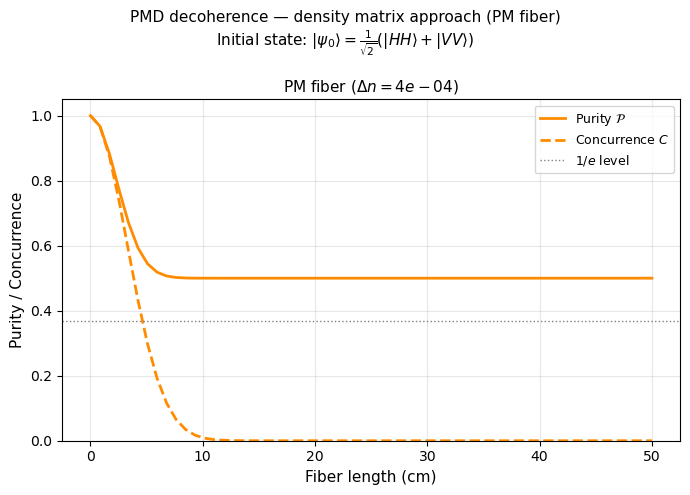

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────
# 1. PHYSICAL PARAMETERS
# ──────────────────────────────────────────────────────────────

c        = 3e8            # speed of light (m/s)
lam0     = 1320e-9        # central wavelength (m)
omega0   = 2*np.pi*c/lam0 # central angular frequency (rad/s)

# Spectral bandwidth: 25 nm FWHM per photon
dlam_fwhm = 25e-9                              # FWHM in wavelength (m)
# Convert to angular frequency std dev:
# sigma_omega = (2*pi*c / lam^2) * (dlam_FWHM / (2*sqrt(2*ln2)))
sigma_omega = (2*np.pi*c / lam0**2) * dlam_fwhm / (2*np.sqrt(2*np.log(2)))

dn_PM  = 4e-4   # PM fiber (PANDA)

# ──────────────────────────────────────────────────────────────
# 2. FREQUENCY GRID
# ──────────────────────────────────────────────────────────────

# Sample +/- 6 sigma around omega0
N_omega  = 500
omega    = np.linspace(omega0 - 6*sigma_omega,
                       omega0 + 6*sigma_omega, N_omega)
d_omega  = omega[1] - omega[0]

# Gaussian spectrum S(omega)
S = np.exp(-0.5 * ((omega - omega0) / sigma_omega)**2)
S /= S.sum() * d_omega   # normalise so integral = 1

# ──────────────────────────────────────────────────────────────
# 3. INITIAL DENSITY MATRIX  rho_0 = |psi><psi|
#    Basis order: |HH>, |HV>, |VH>, |VV>
#    |psi> = (1/sqrt(2)) (|HH> + |VV>)
# ──────────────────────────────────────────────────────────────

psi0 = np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2)
rho0 = np.outer(psi0, psi0.conj())

# ──────────────────────────────────────────────────────────────
# 4. JONES OPERATOR  U(omega) for a birefringent fiber of length L
#    Phase accumulated by H and V:
#      phi_H(omega) = n_H(omega) * L * omega / c
#      phi_V(omega) = n_V(omega) * L * omega / c
#    In the first-order approximation (linear in omega around omega0):
#      n_H(omega) ~ n0  (we absorb the common phase — it cancels)
#      n_V(omega) ~ n0 + dn
#    So the differential phase is:
#      Delta_phi(omega) = dn * L * omega / c
#    U(omega) = diag(1, exp(i * Delta_phi(omega)))   [common phase dropped]
# ──────────────────────────────────────────────────────────────

def jones_operator(omega_val, dn, L):
    """Single-photon Jones operator for one fiber arm."""
    delta_phi = dn * L * omega_val / c
    return np.array([[1,                    0],
                     [0, np.exp(1j * delta_phi)]], dtype=complex)

def two_photon_operator(omega_val, dn, L):
    """U(omega) ⊗ U(omega) in the 4-dimensional two-photon space."""
    U = jones_operator(omega_val, dn, L)
    return np.kron(U, U)

# ──────────────────────────────────────────────────────────────
# 5. INTEGRATE OVER SPECTRUM  →  rho_final
# ──────────────────────────────────────────────────────────────

def compute_rho_final(dn, L):
    """
    rho_final = integral S(omega) * UU(omega) * rho0 * UU†(omega) d_omega
    """
    rho_final = np.zeros((4, 4), dtype=complex)
    for k, om in enumerate(omega):
        UU = two_photon_operator(om, dn, L)
        rho_k = UU @ rho0 @ UU.conj().T
        rho_final += S[k] * rho_k * d_omega
    return rho_final

# ──────────────────────────────────────────────────────────────
# 6. ENTANGLEMENT METRICS
# ──────────────────────────────────────────────────────────────

def purity(rho):
    return np.real(np.trace(rho @ rho))

def concurrence(rho):
    """Wootters concurrence for a 2-qubit state."""
    sigma_y = np.array([[0, -1j], [1j, 0]])
    Y = np.kron(sigma_y, sigma_y)
    rho_tilde = Y @ rho.conj() @ Y
    M = rho @ rho_tilde
    eigs = np.linalg.eigvals(M)
    eigs = np.sqrt(np.abs(eigs.real))
    eigs = np.sort(eigs)[::-1]
    C = max(0.0, eigs[0] - eigs[1] - eigs[2] - eigs[3])
    return float(C)

# ──────────────────────────────────────────────────────────────
# 7. SWEEP OVER FIBER LENGTH L  (PM fiber, 0 to 50 cm)
# ──────────────────────────────────────────────────────────────

L_PM = np.linspace(0, 0.50, 60)

purity_PM      = []
concurrence_PM = []
for L in L_PM:
    rho = compute_rho_final(dn_PM, L)
    purity_PM.append(purity(rho))
    concurrence_PM.append(concurrence(rho))
    print(f"  L={L*100:.1f} cm  P={purity_PM[-1]:.4f}  C={concurrence_PM[-1]:.4f}")

# ──────────────────────────────────────────────────────────────
# 8. PLOT
# ──────────────────────────────────────────────────────────────

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle(
    'PMD decoherence — density matrix approach (PM fiber)\n'
    r'Initial state: $|\psi_0\rangle = \frac{1}{\sqrt{2}}(|HH\rangle + |VV\rangle)$',
    fontsize=11)

ax.plot(L_PM*100, purity_PM, color='darkorange', lw=2, label='Purity $\\mathcal{P}$')
ax.plot(L_PM*100, concurrence_PM, color='darkorange', lw=2,
        linestyle='--', label='Concurrence $C$')
ax.axhline(1/np.e, color='gray', lw=1, linestyle=':', label='$1/e$ level')
ax.set_xlabel('Fiber length (cm)', fontsize=11)
ax.set_ylabel('Purity / Concurrence', fontsize=11)
ax.set_title(f'PM fiber ($\\Delta n = {dn_PM:.0e}$)', fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pmd_density_matrix_pm_only.png', dpi=150, bbox_inches='tight')
plt.show()